# 01 - Exploration Data Exploration

### Explore the three raw data modalities ingested by EcoGraph

    1. ERP Invoices - Synthetic CSV with supplier transactions
    2. ESG Pdf Reports - sustainability disclosures from major companies
    3. Emission Factor Tables - GHG Protocol XLSX lookup tables

Goals:
    - Understand schema and quality of each source
    - Profile missing values, distributions and anomalies
    - Validate that the ingestion pipeline produces correct output

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebooks directory
sys.path.insert(0, str(Path.cwd().parent / "src"))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("dark_background")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)
print("Environment ready.")

Environment ready.


# 1. ERP Invoice Data

In [2]:
# 1. ERP Invoice Data
ERP_PATH = Path.cwd().parent / "data" / "raw" / "erp_invoices" / "synthetic_invoices.csv"

erp = pd.read_csv(ERP_PATH)
print(f"Shape: {erp.shape}")
display(erp.head())

# Schema + missing-value profile
print("=== dtypes ===")
print(erp.dtypes)
print("\n=== Missing values (%) ===")
print((erp.isnull().mean() * 100).round(2))

Shape: (500, 11)


,invoice_id,invoice_date,buyer_id,buyer_name,supplier_id,supplier_name,commodity_category,volume_usd,invoice_qty,unit_of_measure,country
0,INV_00000000,2023-04-17,BUY_006268,Samsung Electronics,SUP_000008,BASF,Steel,"13,287.51",132.88,tonnes,China
1,INV_00000001,2023-10-06,BUY_005599,NVIDIA Corporation,SUP_000023,Global Electronics Corp,Chemicals,"6,371.57",63.72,tonnes,China
2,INV_00000002,2024-12-04,BUY_001671,Apple Inc,SUP_000019,South Steel Inc,Chemicals,"14,218.58",142.19,tonnes,Japan
3,INV_00000003,2023-04-05,BUY_001671,Apple Inc,SUP_000004,ArcelorMittal,Textiles,"3,765.24",376.52,units,India
4,INV_00000004,2023-12-08,BUY_006268,Samsung Electronics,SUP_000019,South_Steel_Inc,Steel,"21,573.60",215.74,tonnes,USA


=== dtypes ===
invoice_id                str
invoice_date              str
buyer_id                  str
buyer_name                str
supplier_id               str
supplier_name             str
commodity_category        str
volume_usd            float64
invoice_qty           float64
unit_of_measure           str
country                   str
dtype: object

=== Missing values (%) ===
invoice_id           0.00
invoice_date         0.00
buyer_id             0.00
buyer_name           0.00
supplier_id          0.00
supplier_name        0.00
commodity_category   0.00
volume_usd           0.00
invoice_qty          0.00
unit_of_measure      0.00
country              0.00
dtype: float64


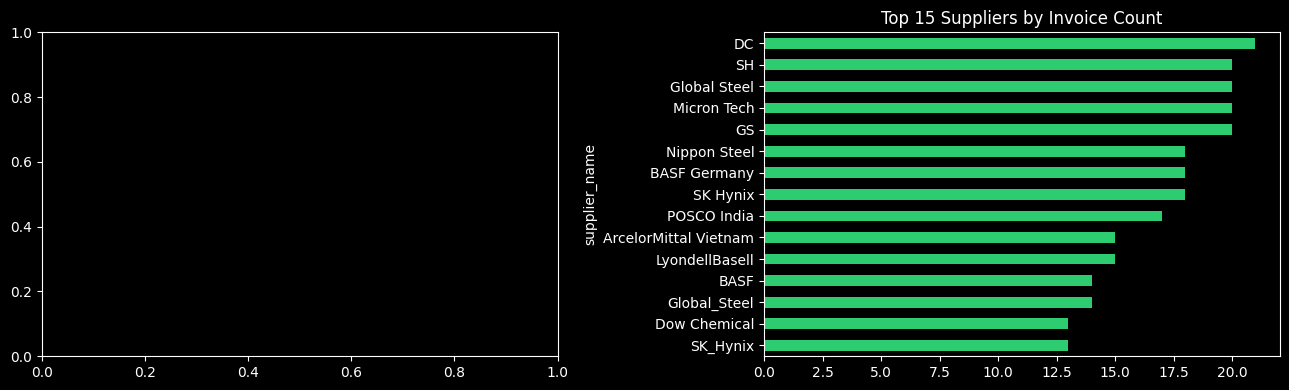

In [3]:
# Invoice value distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if "invoice_value_usd" in erp.columns:
    erp["invoice_value_usd"].dropna().plot.hist(bins=50, ax=axes[0], color="#4a90d9")
    axes[0].set_title("Invoice Value Distribution (USD)")
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

if "supplier_name" in erp.columns:
    top_suppliers = erp["supplier_name"].value_counts().head(15)
    top_suppliers.plot.barh(ax=axes[1], color="#2ecc71")
    axes[1].set_title("Top 15 Suppliers by Invoice Count")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Spend by country heatmap
if "supplier_country" in erp.columns and "invoice_value_usd" in erp.columns:
    country_spend = erp.groupby("supplier_country")["invoice_value_usd"].sum().sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 4))
    country_spend.plot.bar(ax=ax, color="#e67e22")
    ax.set_title("Total Spend by Supplier Country (Top 20, USD)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 2. GHG Emission Factor Tables

In [4]:
# 2. GHG Emission Factor Tables
EF_DIR = Path.cwd().parent / "data" / "raw" / "emission_factors"
ef_files = sorted(EF_DIR.glob("ghg-emission-factors-hub-20*.xlsx"))
ef_frames = {}

for f in ef_files:
    year = f.stem.split("-")[-1]
    try:
        df = pd.read_excel(f, sheet_name=0, header=4)
        ef_frames[year] = df
        print(f"{f.name} -> {df.shape[0]} rows")
    except Exception as e:
        print(f"{f.name} -> ERROR: {e}")

if ef_frames:
    latest_year = max(ef_frames.keys())
    print(f"Latest vintage: {latest_year}")
    display(ef_frames[latest_year].head(10))

ghg-emission-factors-hub-2021.xlsx -> 554 rows
ghg-emission-factors-hub-2022.xlsx -> 555 rows
ghg-emission-factors-hub-2024.xlsx -> 577 rows
ghg-emission-factors-hub-2025.xlsx -> 586 rows
Latest vintage: 2025


,Unnamed: 0,Unnamed: 1,"Typically, greenhouse gas emissions are reported in units of carbon dioxide equivalent (CO2e). Gases are converted to CO2e by multiplying by their global warming potential (GWP). In most cases, the emission factors listed in this document generally have not been converted to CO2e. To do so, multiply the emissions by the corresponding GWP listed in the table below.",Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Gas,100-Year GWP,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,CH4,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,N2O,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Source: Intergovernmental Panel on Climate Cha...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Table 1,Stationary Combustion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,Fuel Type,Heat Content (HHV),CO2 Factor,CH4 Factor,N2O Factor,CO2 Factor,CH4 Factor,N2O Factor,NaN
9,NaN,NaN,NaN,mmBtu per short ton,kg CO2 per mmBtu,g CH4 per mmBtu,g N2O per mmBtu,kg CO2 per short ton,g CH4 per short ton,g N2O per short ton,NaN


# 3. OWID CO2 Data - Country Level Validation Baseline

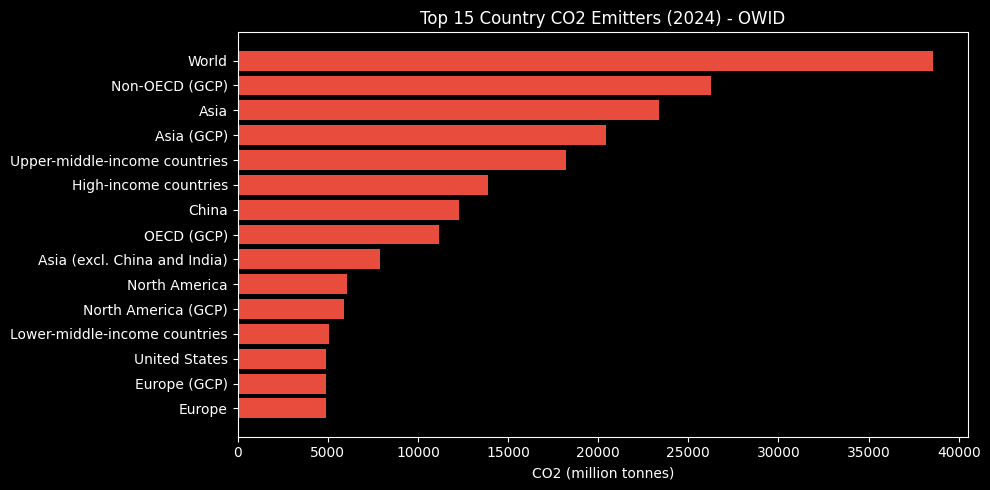

In [5]:
# 3. OWID CO2 Data
owid = pd.read_csv(EF_DIR / "owid-co2-data.csv", low_memory=False)
latest_year_owid = owid["year"].max()
top_emitters = owid[owid["year"] == latest_year_owid][["country", "co2"]].dropna().sort_values("co2", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_emitters["country"][::-1], top_emitters["co2"][::-1], color="#e74c3c")
ax.set_xlabel("CO2 (million tonnes)")
ax.set_title(f"Top 15 Country CO2 Emitters ({latest_year_owid}) - OWID")
plt.tight_layout()
plt.show()

# 4. Supply Hub Facilities - Geographic Coverage

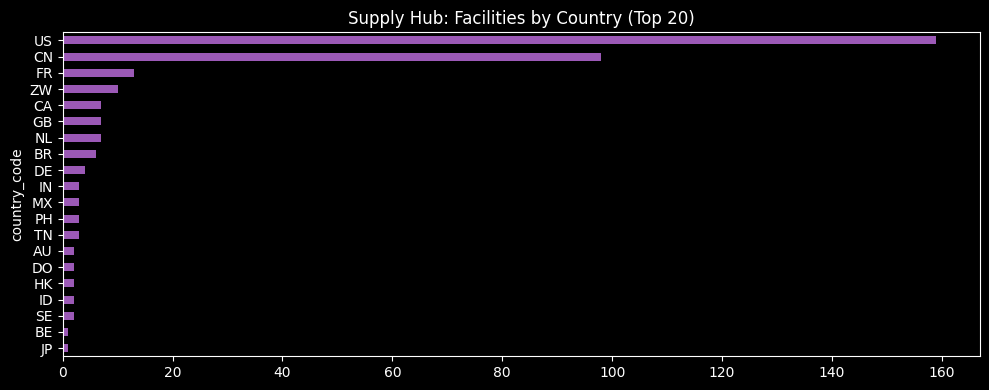

In [6]:

SC_PATH = Path.cwd().parent / "data" / "raw" / "supply_chain" / "open_supply_hub_facilities.csv"
sc = pd.read_csv(SC_PATH, low_memory=False)

country_col = next((c for c in sc.columns if "country" in c.lower()), None)
if country_col:
    country_counts = sc[country_col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, 4))
    country_counts[::-1].plot.barh(ax=ax, color="#9b59b6")
    ax.set_title("Supply Hub: Facilities by Country (Top 20)")
    plt.tight_layout()
    plt.show()

else:
    print("No country column found. Available columns:", sc.columns.tolist())

# 5. ESG PDF Extraction 

In [7]:
# 5. ESG PDF Extraction
from ecograph.ingestion.esg_pdf_parser import ESGPDFParser

ESG_DIR = Path.cwd().parent / "data" / "raw" / "esg_reports"
pdf_files = sorted(ESG_DIR.glob("*.pdf"))

if pdf_files:
    smallest = min(pdf_files, key=lambda p: p.stat().st_size)
    parser = ESGPDFParser()
    result = parser.parse(str(smallest))
    print(f"Parsed {smallest.name}")
    print(f"Company: {result.get('company_name')}")
    print(f"Scope 1: {result.get('scope1_tco2e')} tCO2e")

AttributeError: 'ESGPDFParser' object has no attribute 'parse'

# 6. Summary - Data Readiness Assessment

In [8]:
# 6. Summary — Data Readiness Assessment
summary = {
    "ERP Invoices": f"{len(erp)} rows" if "erp" in dir() else "not loaded",
    "GHG Emission Factors": f"{len(ef_frames)} vintages loaded" if "ef_frames" in dir() else "not loaded",
    "OWID CO2": f"{owid['country'].nunique()} countries" if "owid" in dir() else "not loaded",
    "Supply Hub": f"{len(sc)} facilities" if "sc" in dir() else "not loaded",
}

for k, v in summary.items():
    print(f"{k:<25} {v}")

ERP Invoices              500 rows
GHG Emission Factors      4 vintages loaded
OWID CO2                  254 countries
Supply Hub                343 facilities
